<a href="https://colab.research.google.com/github/paulrobustelli/CHEM6_S25/blob/main/Fit_POB_models_instructor_4_22_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [635]:
import matplotlib as mpl # matplotlib library for plotting and visualization
import matplotlib.pylab as plt # matplotlib library for plotting and visualization
import numpy as np #numpy library for numerical manipulation, especially suited for data arrays
import warnings
import scipy, scipy.optimize
from mpl_toolkits.mplot3d import  Axes3D
from matplotlib import cm # to colormap 3D surfaces from blue to red

warnings.filterwarnings('ignore')


**Liner Regression Example:**

Here is some data we will use to illustrate how to perfrom a regression:

x_data=np.array([29, 9, 10, 38, 16, 26, 50, 10, 30, 33, 43, 2, 39, 15, 44, 29, 41, 15, 24, 50])

y_data=np.array([65, 7, 8, 76, 23, 56, 100, 3, 74, 48, 73, 0, 62, 37, 74, 40, 90, 42, 58, 100])


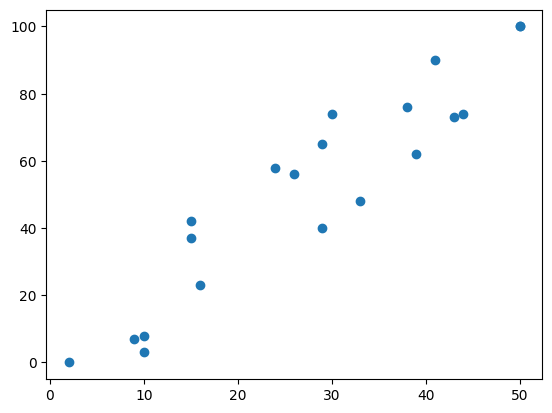

9 7


In [636]:
#Liner Regression Example: https://data36.com/linear-regression-in-python-numpy-polyfit/
#Here is some date we will use to illustrate how to perfrom a regression:

x_data=np.array([29, 9, 10, 38, 16, 26, 50, 10, 30, 33, 43, 2, 39, 15, 44, 29, 41, 15, 24, 50])
y_data=np.array([65, 7, 8, 76, 23, 56, 100, 3, 74, 48, 73, 0, 62, 37, 74, 40, 90, 42, 58, 100])

#Here is how to make a simple plot
plt.scatter(x_data,y_data)
plt.show()
print(x_data[1],y_data[1])

Fitting Polynomial Models in Python

Now we are going to use a Python function to fit our data.

Instead of returning just coefficients, we will build a model object that represents the polynomial. We can then use this model to evaluate (predict) values.

We will use the Polynomial.fit function from NumPy.

1st degree polynomial (line):
$$y = a x + b$$

line_model = Polynomial.fit(x_data, y_data, deg=1)

2nd degree polynomial (quadratic):
$$y = a x^2 + b x + c$$

quad_model = Polynomial.fit(x_data, y_data, deg=2)

3rd degree polynomial (cubic):
$$y = a x^3 + b x^2 + c x + d$$

cubic_model = Polynomial.fit(x_data, y_data, deg=3)

Each of these creates a model that behaves like a function. For example, after fitting a line:

y_pred = line_model(x_new)


In [638]:
from numpy.polynomial import Polynomial

# Fit a line (1st degree polynomial)
line_model = Polynomial.fit(x_data, y_data, deg=1)

# Print the fitted model
print(line_model)

# Convert to standard polynomial form (so coefficients are easy to interpret)
line_standard = line_model.convert()

# Print equation form
print("y = a*x + b")

# Extract coefficients
# Note: coefficients are stored as [b, a] (constant term first)
b = line_standard.coef[0]
a = line_standard.coef[1]

print("a:", a)
print("b:", b)

48.47578646 + 48.35219691·(-1.08333333 + 0.04166667x)
y = a*x + b
a: 2.0146748714407257
b: -3.9057601953360717


Plotting the Function We Have Fit

Now we want to plot the line that our model has learned.

Instead of manually using coefficients, we will use our model object to generate predictions.

To do this, we create an array of x-values that we will pass into our model to generate y-values.

We use np.linspace to create an array of evenly spaced values from 0 to 50:

x_range = np.linspace(0, 50, 51)

We then evaluate our fitted model at these x-values to generate the corresponding y-values:

y_fit = line_model(x_range)

51
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34. 35.
 36. 37. 38. 39. 40. 41. 42. 43. 44. 45. 46. 47. 48. 49. 50.]
51
[-3.9057602  -1.89108532  0.12358955  2.13826442  4.15293929  6.16761416
  8.18228903 10.1969639  12.21163878 14.22631365 16.24098852 18.25566339
 20.27033826 22.28501313 24.299688   26.31436288 28.32903775 30.34371262
 32.35838749 34.37306236 36.38773723 38.4024121  40.41708698 42.43176185
 44.44643672 46.46111159 48.47578646 50.49046133 52.50513621 54.51981108
 56.53448595 58.54916082 60.56383569 62.57851056 64.59318543 66.60786031
 68.62253518 70.63721005 72.65188492 74.66655979 76.68123466 78.69590953
 80.71058441 82.72525928 84.73993415 86.75460902 88.76928389 90.78395876
 92.79863363 94.81330851 96.82798338]


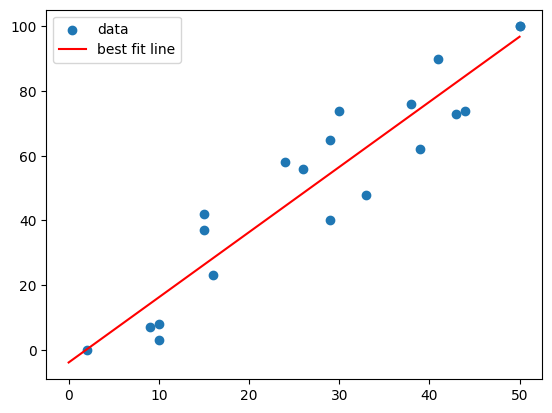

In [639]:
import numpy as np
import matplotlib.pyplot as plt

# Create a range of x values
x_range = np.linspace(0, 50, 51)

# Evaluate the fitted model to get y values
y_fit = line_model(x_range)

# Check lengths and values
print(len(x_range))
print(x_range)

print(len(y_fit))
print(y_fit)

# Plot data and fitted line
plt.scatter(x_data, y_data, label='data')
plt.plot(x_range, y_fit, c='r', label='best fit line')
plt.legend()
plt.show()

### Calculating the Coefficient of Determination, $R^2$

Now we want to quantify how well our fitted model describes the data.

The **coefficient of determination**, $R^2$, compares the total variation in the data to the variation that remains after fitting the model.

First, we compute the **mean** of the data:

$$
\bar{y} = \frac{1}{N} \sum_{i=1}^{N} y_i
$$

Next, we calculate the **total sum of squares** (total variation in the data):

$$
SS_{\text{tot}} = \sum_{i=1}^{N} (y_i - \bar{y})^2
$$

Then, we calculate the **residual sum of squares** (unexplained variation after fitting):

$$
SS_{\text{res}} = \sum_{i=1}^{N} (y_i - \hat{y}_i)^2
$$

where $\hat{y}_i$ are the values predicted by our model.

Finally, we compute $R^2$:

$$
R^2 = 1 - \frac{SS_{\text{res}}}{SS_{\text{tot}}}
$$

An $R^2$ value close to 1 means the model explains most of the variation in the data, while a value close to 0 means it explains very little.

In [267]:
def calc_r_squared(y_true, y_pred):
    y_mean = np.mean(y_true)
    SS_tot = np.sum((y_true - y_mean)**2)
    SS_res = np.sum((y_true - y_pred)**2)
    return 1 - SS_res / SS_tot


# Predictions from model
y_predict = line_model(x_data)

# Compute R^2
R2 = calc_r_squared(y_data, y_predict)

print("R^2:", R2)

R^2: 0.8777480188408424


**Class Exercise**

Now let's do the following together:

1) Fit a 2nd Order

2) Print out the coefficients

3) Plot data vs. fit polynomials on the range x=[-50,50] (x going form -50 to 50)

4) Calculate the Correlation Coefficient of the Fit



In [640]:
#Complete Class Activity here
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial import Polynomial
import matplotlib as mpl # matplotlib library for plotting and visualization
import matplotlib.pylab as plt # matplotlib library for plotting and visualization

x_data=np.array([29, 9, 10, 38, 16, 26, 50, 10, 30, 33, 43, 2, 39, 15, 44, 29, 41, 15, 24, 50])
y_data=np.array([65, 7, 8, 76, 23, 56, 100, 3, 74, 48, 73, 0, 62, 37, 74, 40, 90, 42, 58, 100])


50.61278223 + 48.90203618·(-1.08333333 + 0.04166667x) -
6.09726551·(-1.08333333 + 0.04166667x)²
y = a*x^2 + b*x + c
a: -0.010585530391008883
b: 2.588032421316212
c: -9.52024217868992


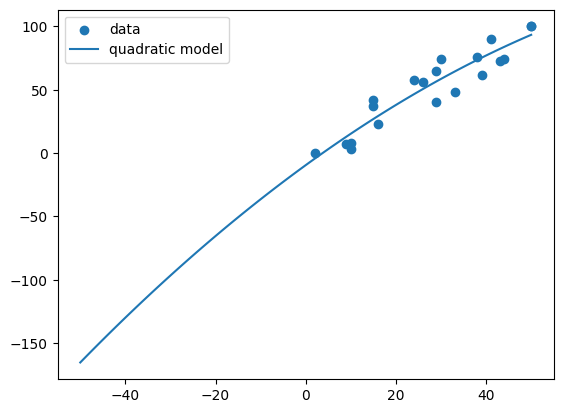

R^2: 0.8817956886030568


In [641]:
#Class Activity Instructor Solution

import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial import Polynomial

# 1. Fit a quadratic model (2nd order polynomial)
quadratic_model = Polynomial.fit(x_data, y_data, deg=2)

print(quadratic_model)
# Convert to poynomail into a form to extract coefficients
quadratic_standard = quadratic_model.convert()

# 2. Print coefficients
# Note: order is [c, b, a]
c = quadratic_standard.coef[0]
b = quadratic_standard.coef[1]
a = quadratic_standard.coef[2]

print("y = a*x^2 + b*x + c")
print("a:", a)
print("b:", b)
print("c:", c)

# 3. Generate smooth x-range and predictions
x_range = np.linspace(-50, 50, 101)
y_fit = quadratic_model(x_range)

# Plot
plt.scatter(x_data, y_data, label='data')
plt.plot(x_range, y_fit, label='quadratic model')
plt.legend()
plt.show()

# 4. Calculate R^2
#def calc_r_squared(y_true, y_pred):
#    y_mean = np.mean(y_true)
#    SS_tot = np.sum((y_true - y_mean)**2)
#    SS_res = np.sum((y_true - y_pred)**2)
#    return 1 - SS_res / SS_tot

y_predict = quadratic_model(x_data)
R2 = calc_r_squared(y_data, y_predict)

print("R^2:", R2)

**Homework Exercise #1**

1) Fit a 3rd Order Polynomial

2) Print out the coefficients

3) Plot data vs. fit polynomials on the range x=[-50,50] (x going form -50 to 50)

4) Calculate the Correlation Coefficient of the Fit



In [270]:
#Complete Homework activity here
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial import Polynomial
import matplotlib as mpl # matplotlib library for plotting and visualization
import matplotlib.pylab as plt # matplotlib library for plotting and visualization

x_data=np.array([29, 9, 10, 38, 16, 26, 50, 10, 30, 33, 43, 2, 39, 15, 44, 29, 41, 15, 24, 50])
y_data=np.array([65, 7, 8, 76, 23, 56, 100, 3, 74, 48, 73, 0, 62, 37, 74, 40, 90, 42, 58, 100])


51.04842847 + 41.40993367·(-1.08333333 + 0.04166667x) -
7.73237626·(-1.08333333 + 0.04166667x)² +
11.77823826·(-1.08333333 + 0.04166667x)³
y = a*x^3 + b*x^2 + cx +d
a: 0.000852013762985791
b: -0.07988133786155242
c: 4.151359560426092
c: -17.86212960852194


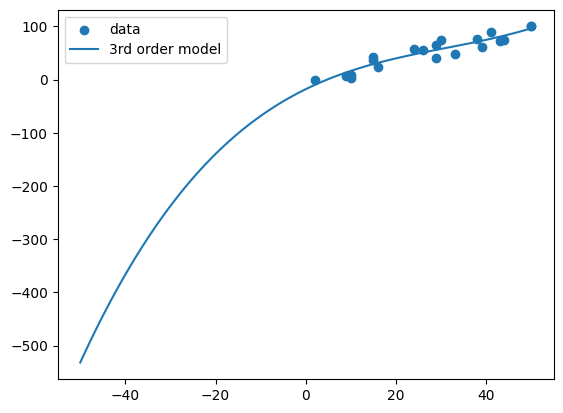

R^2: 0.8867312025237684


In [642]:
# Homework Exercise 1 solution

import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial import Polynomial

x_data=np.array([29, 9, 10, 38, 16, 26, 50, 10, 30, 33, 43, 2, 39, 15, 44, 29, 41, 15, 24, 50])
y_data=np.array([65, 7, 8, 76, 23, 56, 100, 3, 74, 48, 73, 0, 62, 37, 74, 40, 90, 42, 58, 100])

# 1. Fit a quadratic model (3rd order polynomial)
poly3_model = Polynomial.fit(x_data, y_data, deg=3)

print(poly3_model)
# Convert to poynomail into a form to extract coefficients
poly3_model = poly3_model.convert()

# 2. Print coefficients
# Note: order is [d,c, b, a]
d = poly3_model.coef[0]
c = poly3_model.coef[1]
b = poly3_model.coef[2]
a = poly3_model.coef[3]

print("y = a*x^3 + b*x^2 + cx +d")
print("a:", a)
print("b:", b)
print("c:", c)
print("c:", d)

# 3. Generate smooth x-range and predictions
x_range = np.linspace(-50, 50, 101)
y_fit = poly3_model(x_range)

# Plot
plt.scatter(x_data, y_data, label='data')
plt.plot(x_range, y_fit, label='3rd order model')
plt.legend()
plt.show()

# 4. Calculate R^2
#def calc_r_squared(y_true, y_pred):
#    y_mean = np.mean(y_true)
#    SS_tot = np.sum((y_true - y_mean)**2)
#    SS_res = np.sum((y_true - y_pred)**2)
#    return 1 - SS_res / SS_tot

y_predict = poly3_model(x_data)
R2 = calc_r_squared(y_data, y_predict)

print("R^2:", R2)


Now Lets Fit some Higher Order polynomials and explore the quality of the fit

1st order polynomial
-3.9057602 + 2.01467487·x
R^2: 0.8777480188408424

2nd order polynomial
-9.52024218 + 2.58803242·x - 0.01058553·x²
R^2: 0.8817956886030568

10th order polynomial
-899.491604 + 838.56605371·x - 264.79367411·x² + 42.20538661·x³ -
3.93227391·x⁴ + 0.22948725·x⁵ - 0.00863273·x⁶ + 0.00020905·x⁷ -
(3.14575543e-06)·x⁸ + (2.67473514e-08)·x⁹ - (9.813508e-11)·x¹⁰
R^2: 0.9314269716125649

20th order polynomial
10270194.79937513 - 12042833.93539176·x + 5571710.09393342·x² -
1452208.1791148·x³ + 246146.35535942·x⁴ - 29216.34756214·x⁵ +
2528.39797872·x⁶ - 162.32145036·x⁷ + 7.66963632·x⁸ - 0.25137908·x⁹ +
0.00429362·x¹⁰ + (7.5732247e-05)·x¹¹ - (8.6651845e-06)·x¹² +
(3.55213275e-07)·x¹³ - (9.62339413e-09)·x¹⁴ + (1.8921353e-10)·x¹⁵ -
(2.74409893e-12)·x¹⁶ + (2.88348003e-14)·x¹⁷ - (2.0869857e-16)·x¹⁸ +
(9.33443462e-19)·x¹⁹ - (1.94780814e-21)·x²⁰
R^2: 0.9819992319672306



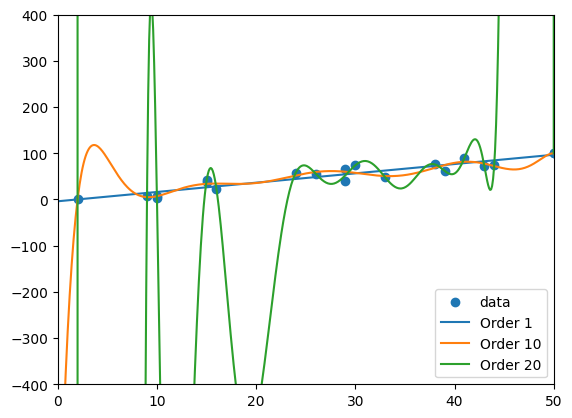

In [643]:
# Now let's fit some really high-order polynomials to our data for fun

from numpy.polynomial import Polynomial
import numpy as np
import matplotlib.pyplot as plt


def calc_r_squared(y_true, y_pred):
    y_mean = np.mean(y_true)
    SS_tot = np.sum((y_true - y_mean)**2)
    SS_res = np.sum((y_true - y_pred)**2)
    return 1 - SS_res / SS_tot


# Fit models of different polynomial degree
linear_model = Polynomial.fit(x_data, y_data, deg=1)
quadratic_model = Polynomial.fit(x_data, y_data, deg=2)
degree_10_model = Polynomial.fit(x_data, y_data, deg=10)
degree_20_model = Polynomial.fit(x_data, y_data, deg=20)

# Print models and R^2 values
print("1st order polynomial")
print(linear_model.convert())
R2 = calc_r_squared(y_data, linear_model(x_data))
print("R^2:", R2)
print()

print("2nd order polynomial")
print(quadratic_model.convert())
R2 = calc_r_squared(y_data, quadratic_model(x_data))
print("R^2:", R2)
print()

print("10th order polynomial")
print(degree_10_model.convert())
R2 = calc_r_squared(y_data, degree_10_model(x_data))
print("R^2:", R2)
print()

print("20th order polynomial")
print(degree_20_model.convert())
R2 = calc_r_squared(y_data, degree_20_model(x_data))
print("R^2:", R2)
print()

# Generate smooth x values for plotting
x_range = np.linspace(0, 50, 500)

# Predict y values from each model
y_fit_1 = linear_model(x_range)
y_fit_10 = degree_10_model(x_range)
y_fit_20 = degree_20_model(x_range)

# Plot data and model curves
plt.scatter(x_data, y_data, label='data')
plt.plot(x_range, y_fit_1, label='Order 1')
plt.plot(x_range, y_fit_10, label='Order 10')
plt.plot(x_range, y_fit_20, label='Order 20')
plt.ylim(-400, 400)
plt.xlim(0, 50)
plt.legend()
plt.show()

**Homework Exercise 2**

Use polyfit to fit a 3rd, 4th, and 5th order polynomial to our data, and plot the functions from on the range x=(-50,50) on the same

In [644]:
#Complete Homework Problem 3 Here
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial import Polynomial
import matplotlib as mpl # matplotlib library for plotting and visualization
import matplotlib.pylab as plt # matplotlib library for plotting and visualization

x_data=np.array([29, 9, 10, 38, 16, 26, 50, 10, 30, 33, 43, 2, 39, 15, 44, 29, 41, 15, 24, 50])
y_data=np.array([65, 7, 8, 76, 23, 56, 100, 3, 74, 48, 73, 0, 62, 37, 74, 40, 90, 42, 58, 100])

1st order polynomial
-3.9057602 + 2.01467487·x
R^2: 0.8777480188408424

3rd order polynomial
-17.86212961 + 4.15135956·x - 0.07988134·x² + 0.00085201·x³
R^2: 0.8867312025237684

4th order polynomial
-2.97572062 - 0.74254827·x + 0.32838108·x² - 0.01118938·x³ + 0.00011495·x⁴
R^2: 0.9030912305839351

5th order polynomial
13.84614746 - 9.92888343·x + 1.52438632·x² - 0.07090828·x³ +
0.00138064·x⁴ - (9.58293443e-06)·x⁵
R^2: 0.912752617900205



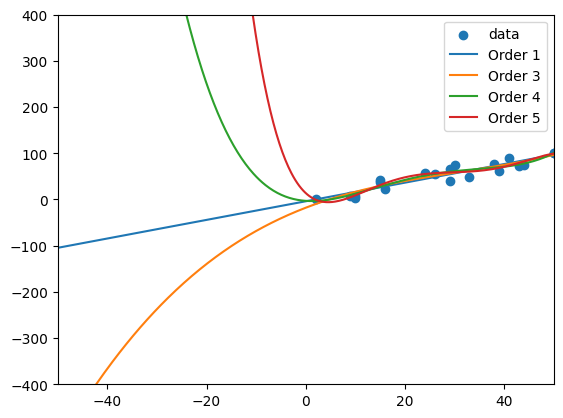

In [645]:
#Homework Exercise 2 Solution

#import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial import Polynomial

# Data
x_data = np.array([29, 9, 10, 38, 16, 26, 50, 10, 30, 33, 43, 2, 39, 15, 44, 29, 41, 15, 24, 50])
y_data = np.array([65, 7, 8, 76, 23, 56, 100, 3, 74, 48, 73, 0, 62, 37, 74, 40, 90, 42, 58, 100])

# R^2 function
def calc_r_squared(y_true, y_pred):
    y_mean = np.mean(y_true)
    SS_tot = np.sum((y_true - y_mean)**2)
    SS_res = np.sum((y_true - y_pred)**2)
    return 1 - SS_res / SS_tot


# ---- Fit models ----
linear_model = Polynomial.fit(x_data, y_data, deg=1)
cubic_model = Polynomial.fit(x_data, y_data, deg=3)
quartic_model = Polynomial.fit(x_data, y_data, deg=4)
quintic_model = Polynomial.fit(x_data, y_data, deg=5)


# ---- Print models + R^2 ----
print("1st order polynomial")
print(linear_model.convert())
print("R^2:", calc_r_squared(y_data, linear_model(x_data)))
print()

print("3rd order polynomial")
print(cubic_model.convert())
print("R^2:", calc_r_squared(y_data, cubic_model(x_data)))
print()

print("4th order polynomial")
print(quartic_model.convert())
print("R^2:", calc_r_squared(y_data, quartic_model(x_data)))
print()

print("5th order polynomial")
print(quintic_model.convert())
print("R^2:", calc_r_squared(y_data, quintic_model(x_data)))
print()


# ---- Plot ----
x_range = np.linspace(-50, 50, 500)

y_fit_1 = linear_model(x_range)
y_fit_3 = cubic_model(x_range)
y_fit_4 = quartic_model(x_range)
y_fit_5 = quintic_model(x_range)

plt.scatter(x_data, y_data, label='data')

plt.plot(x_range, y_fit_1, label='Order 1')
plt.plot(x_range, y_fit_3, label='Order 3')
plt.plot(x_range, y_fit_4, label='Order 4')
plt.plot(x_range, y_fit_5, label='Order 5')

plt.ylim(-400, 400)
plt.xlim(-50, 50)
plt.legend()
plt.show()

#### Calculating the Root Mean Squared Deviation (RMSD)

We now introduce a second way to measure how well our model fits the data.

The **Root Mean Squared Deviation (RMSD)** measures the average size of the errors between the predicted values and the actual data.

First, we compute the residuals:

$$
r_i = y_i - \hat{y}_i
$$

Then we square those residuals, average them, and take the square root:

$$
RMSD = \left[ \frac{1}{N}\sum_{i=1}^{N}(y_i-\hat{y}_i)^2 \right]^{1/2}
$$

where:

- $y_i$ are the observed data points
- $\hat{y}_i$ are the values predicted by the model
- $N$ is the number of data points

A smaller RMSD means the model predictions are closer to the data.

**Class Activity**

Lets Write a function to compute the RMSD

Functions work like this in python

```python

def function(input_array1,input_array2):
  #do some stuff
  #output=some stuff
  return output

In [650]:
#CLASS EXERCISE
def calculate_RMSD(y_true, y_pred):
  #ADD CODE HERE
  #return(something)
  return()

In [654]:
#CLASROOM SOLUTION
def calculate_RMSD(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2))

Now lets calculte the RMSD of some different polynomials

In [657]:
y_pred_1 = linear_model(x_data)
y_pred_10 = degree_10_model(x_data)
y_pred_20 = degree_20_model(x_data)

# Calculate RMSD
RMSD_1 = calculate_RMSD(y_data, y_pred_1)
print("RMSD (1st order / linear model):", RMSD_1)

RMSD_10 = calculate_RMSD(y_data, y_pred_10)
print("RMSD (10th order model):", RMSD_10)

RMSD_20 = calculate_RMSD(y_data, y_pred_20)
print("RMSD (20th order model):", RMSD_20)

RMSD (1st order / linear model): 10.705435173661266
RMSD (10th order model): 8.01775973649029
RMSD (20th order model): 4.107919181288746


### Using a For Loop in Python

A **for loop** lets us repeat a block of code multiple times.

We will use a loop to go through a sequence of numbers.

The general structure is:

```python
for variable in range(start, stop):
    # code that runs each time

In [662]:
##Class Activitiy###
##Have clase print a For Loop##
start=1
stop=5
for variable in range(start, stop):
    # code that runs each time
    print()

In [663]:
#INSTRUCTOR SOLUTION
start=1
stop=5
for i in range(0,5):
  print("WASSSSSUPPPP",i)

WASSSSSUPPPP 0
WASSSSSUPPPP 1
WASSSSSUPPPP 2
WASSSSSUPPPP 3
WASSSSSUPPPP 4


Now let's make a loop to check the fit of a bunch of polynomial models


In [665]:
# Now let's make a loop to check the fit of a bunch of polynomial models
#ADD CODE HERE
# Make empty lists to store results
polynomial_order = []
polynomial_rmsd = []

#COMPUTE RMSD FOR DIFFERENT POLYNOMIALS


#plt RMSD vs. polynomial order

Polynomial Order: 0 RMSD: 30.617968580557395
Polynomial Order: 1 RMSD: 10.705435173661266
Polynomial Order: 2 RMSD: 10.526719040716266
Polynomial Order: 3 RMSD: 10.304609011605834
Polynomial Order: 4 RMSD: 9.531426702062191
Polynomial Order: 5 RMSD: 9.043833856461198
Polynomial Order: 6 RMSD: 8.883249989221937
Polynomial Order: 7 RMSD: 8.63997201825078
Polynomial Order: 8 RMSD: 8.341021188124413
Polynomial Order: 9 RMSD: 8.151099428243006
Polynomial Order: 10 RMSD: 8.01775973649029
Polynomial Order: 11 RMSD: 7.814315336820715
Polynomial Order: 12 RMSD: 7.075713142745639
Polynomial Order: 13 RMSD: 6.922663643374498
Polynomial Order: 14 RMSD: 6.795281323897134
Polynomial Order: 15 RMSD: 4.107919181288746
Polynomial Order: 16 RMSD: 4.107919181288746
Polynomial Order: 17 RMSD: 4.107919181288747
Polynomial Order: 18 RMSD: 4.107919181288746
Polynomial Order: 19 RMSD: 4.107919181288747
Polynomial Order: 20 RMSD: 4.107919181288746


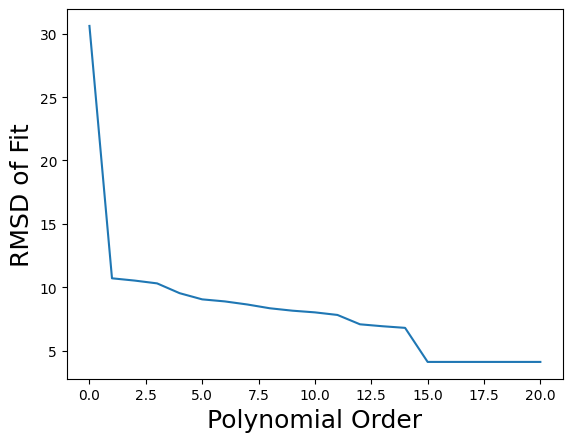

In [666]:
#SOLUTION
# Now let's make a loop to check the fit of a bunch of polynomial models

# Make empty lists to store results
polynomial_order = []
polynomial_rmsd = []

for i in range(0, 21):
    model = Polynomial.fit(x_data, y_data, deg=i)
    y_pred = model(x_data)
    rmsd = calculate_RMSD(y_data, y_pred)

    polynomial_order.append(i)
    polynomial_rmsd.append(rmsd)

    print("Polynomial Order:", i, "RMSD:", rmsd)

# Plot RMSD vs polynomial order
plt.plot(polynomial_order, polynomial_rmsd)
plt.xlabel('Polynomial Order', size=18)
plt.ylabel('RMSD of Fit', size=18)
plt.show()

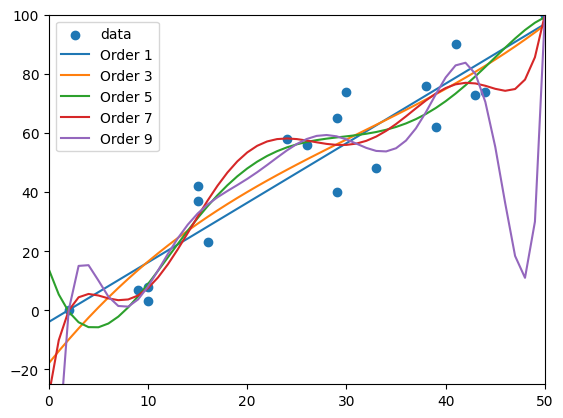

In [667]:
#We can also use a loop to plot these functions
x_data = np.array([29, 9, 10, 38, 16, 26, 50, 10, 30, 33, 43, 2, 39, 15, 44, 29, 41, 15, 24, 50])
y_data = np.array([65, 7, 8, 76, 23, 56, 100, 3, 74, 48, 73, 0, 62, 37, 74, 40, 90, 42, 58, 100])

x_range = np.linspace(0, 50, 51)
plt.scatter(x_data, y_data, label='data')

for i in range(1, 10,2):
    model = Polynomial.fit(x_data, y_data, deg=i)
    y_pred = model(x_range)
    plt.plot(x_range, y_pred, label=f'Order {i}')

plt.ylim(-25, 100)
plt.xlim(0, 50)
plt.legend()
plt.show()

Now lets split our data points into two subsets, fit half to half them, and then and calculated the RMSD of the fit to our fitting data and to our witheld data


Original indices:
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
Shuffled indices:
[ 0 17 15  1  8  5 11  3 18 16 13  2  9 19  4 12  7 10 14  6]
Fit indices:
[ 0 17 15  1  8  5 11  3 18 16]
Validation indices:
[13  2  9 19  4 12  7 10 14  6]
Fit x-values:
[29 15 29  9 30 26  2 38 24 41]
Fit y-values:
[65 42 40  7 74 56  0 76 58 90]
Validation x-values:
[15 10 33 50 16 39 10 43 44 50]
Validation y-values:
[ 37   8  48 100  23  62   3  73  74 100]


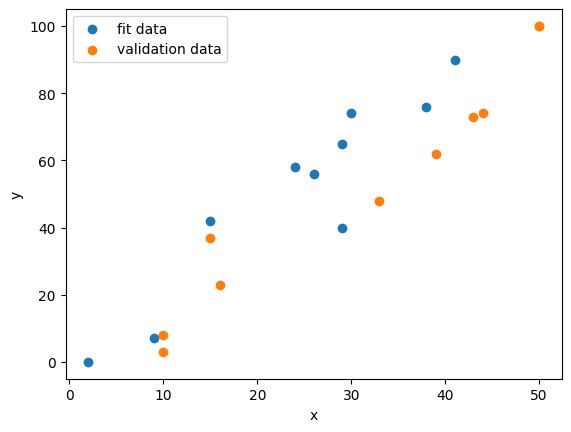

In [668]:
import numpy as np
import matplotlib.pyplot as plt

# Our full dataset:
# x_data contains the x-values
# y_data contains the corresponding y-values
x_data = np.array([29, 9, 10, 38, 16, 26, 50, 10, 30, 33, 43, 2, 39, 15, 44, 29, 41, 15, 24, 50])
y_data = np.array([65, 7, 8, 76, 23, 56, 100, 3, 74, 48, 73, 0, 62, 37, 74, 40, 90, 42, 58, 100])

# ---------------------------------------------
# STEP 1: Make an array of index positions
# ---------------------------------------------
# len(x_data) is 20, so np.arange(len(x_data)) makes:
# [0, 1, 2, 3, ..., 19]
# These are the positions of the data points in our arrays.
indices = np.arange(len(x_data))

# Print the original indices so we can see them before shuffling
print("Original indices:")
print(indices)

# ---------------------------------------------
# STEP 2: Shuffle the indices
# ---------------------------------------------
# Setting a random seed makes the shuffle reproducible.
# That means every time we run this code, we get the same shuffled order.
# This is useful for teaching and debugging.
np.random.seed(42)

# Shuffle the indices in place
np.random.shuffle(indices)

# Print the shuffled indices
print("Shuffled indices:")
print(indices)

# ---------------------------------------------
# STEP 3: Split the shuffled indices into two halves
# ---------------------------------------------
# len(x_data) // 2 means integer division by 2.
# Since we have 20 data points, split = 10.
# So we will use 10 points for fitting and 10 for validation.
split = len(x_data) // 2

# The first half of the shuffled indices will be used for fitting
fit_idx = indices[:split]

# The second half of the shuffled indices will be used for validation
validate_idx = indices[split:]

# Print the two groups of index positions
print("Fit indices:")
print(fit_idx)

print("Validation indices:")
print(validate_idx)

# ---------------------------------------------
# STEP 4: Use those indices to select x-values
# ---------------------------------------------
# x_data[fit_idx] means:
# "give me the x-values at the positions listed in fit_idx"
fit_x = x_data[fit_idx]

# x_data[validate_idx] means:
# "give me the x-values at the positions listed in validate_idx"
validate_x = x_data[validate_idx]

# ---------------------------------------------
# STEP 5: Use the same indices to select y-values
# ---------------------------------------------
# This is very important:
# We must use the SAME shuffled indices for x and y
# so that each x-value stays paired with the correct y-value.
fit_y = y_data[fit_idx]
validate_y = y_data[validate_idx]

# ---------------------------------------------
# STEP 6: Print the two subsets
# ---------------------------------------------
# These are the data points we will use for fitting the model
print("Fit x-values:")
print(fit_x)

print("Fit y-values:")
print(fit_y)

# These are the data points we will hold back for validation
print("Validation x-values:")
print(validate_x)

print("Validation y-values:")
print(validate_y)

# ---------------------------------------------
# STEP 7: Plot the two subsets
# ---------------------------------------------
# Plot the fitting data points
plt.scatter(fit_x, fit_y, label='fit data')

# Plot the validation data points
plt.scatter(validate_x, validate_y, label='validation data')

# Add axis labels and a legend so the plot is easier to interpret
plt.xlabel('x')
plt.ylabel('y')
plt.legend()

# Show the plot
plt.show()

Lets compare the RMSD of the fits on training for test data

Polynomial Order: 0 Fit RMSD: 27.719307350653622 Validate RMSD: 33.29504467634786
Polynomial Order: 1 Fit RMSD: 9.542079781817417 Validate RMSD: 15.499917700422353
Polynomial Order: 2 Fit RMSD: 9.400160410611521 Validate RMSD: 13.879424575391129
Polynomial Order: 3 Fit RMSD: 9.29329547557242 Validate RMSD: 16.43628790495362
Polynomial Order: 4 Fit RMSD: 8.36895197691902 Validate RMSD: 70.28201179084405


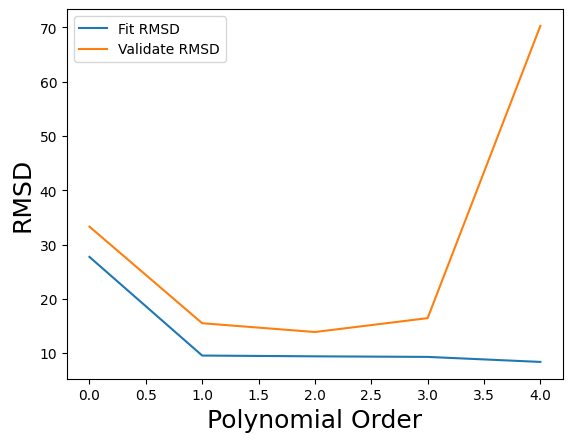

In [673]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial import Polynomial

x = np.linspace(0, 50, 51)

x_data = np.array([29, 9, 10, 38, 16, 26, 50, 10, 30, 33, 43, 2, 39, 15, 44, 29, 41, 15, 24, 50])
y_data = np.array([65, 7, 8, 76, 23, 56, 100, 3, 74, 48, 73, 0, 62, 37, 74, 40, 90, 42, 58, 100])

fit_x = np.array([29, 15, 29, 9, 30, 26, 2, 38, 24, 41])
fit_y = np.array([65, 42, 40, 7, 74, 56, 0, 76, 58, 90])

validate_x = np.array([15, 10, 33, 50, 16, 39, 10, 43, 44, 50])
validate_y = np.array([37, 8, 48, 100, 23, 62, 3, 73, 74, 100])

# Make empty lists to store values for plotting
polynomial_order = []
polynomial_rmsd_fit = []
polynomial_rmsd_validate = []

for i in range(0, 5):
    model = Polynomial.fit(fit_x, fit_y, deg=i)

    y_predict_fit = model(fit_x)
    y_predict_validate = model(validate_x)

    RMSD_fit = calculate_RMSD(fit_y, y_predict_fit)
    RMSD_validate = calculate_RMSD(validate_y, y_predict_validate)

    polynomial_order.append(i)
    polynomial_rmsd_fit.append(RMSD_fit)
    polynomial_rmsd_validate.append(RMSD_validate)

    print("Polynomial Order:", i, "Fit RMSD:", RMSD_fit, "Validate RMSD:", RMSD_validate)

plt.plot(polynomial_order, polynomial_rmsd_fit, label='Fit RMSD')
plt.plot(polynomial_order, polynomial_rmsd_validate, label='Validate RMSD')

plt.xlabel('Polynomial Order', size=18)
plt.ylabel('RMSD', size=18)
plt.legend()
plt.show()

### Particle in a Box (Connecting to Our Data Analysis)

Recall the 1D **particle in a box** wavefunction:

$$
\psi_n(x) = \sqrt{\frac{2}{L}} \sin\left(\frac{n\pi x}{L}\right)
$$

The probability distribution for finding the particle is given by:

$$
P(x) = |\psi_n(x)|^2 = \frac{2}{L} \sin^2\left(\frac{n\pi x}{L}\right)
$$

---

### What we are going to do

Now we will use the tools we’ve developed (model fitting, RMSD, etc.) to:

- Compare different candidate wavefunctions to data  
- Determine which value of \(n\) best describes a given position distribution  
- Quantify how well each model matches the data  

In other words, we are going to **treat each possible \(n\) as a model** and use our fitting tools to figure out which one best explains the data.
Why this is better (for your flow)

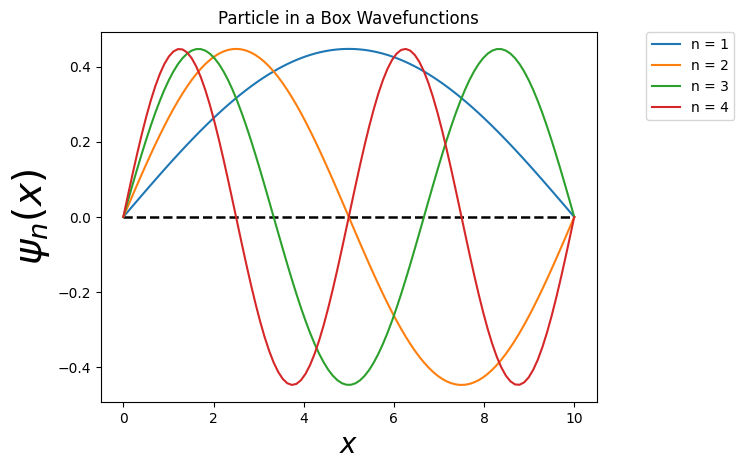

In [674]:
def psi(x, n, L):
    return np.sqrt(2.0 / L) * np.sin(n * np.pi * x / L)

# Let's plot some wavefunctions using a loop

# Length of box in Angstroms
L = 10

# x-values from 0 to L
x = np.linspace(0, L, 100)

# Add horizontal line at y = 0
plt.hlines(0.0, 0.0, L, linewidth=1.8, linestyle='--', color='black')

# Loop over quantum numbers
for n in range(1, 5):
    plt.plot(x, psi(x, n, L), label=f'n = {n}')

plt.xlabel(r'$x$', size=20)
plt.ylabel(r'$\psi_n(x)$', size=28)
plt.title('Particle in a Box Wavefunctions')

plt.legend(bbox_to_anchor=(1.1, 1), loc=2, borderaxespad=0.0)
plt.show()

**CLASS ACTIVITY**

Lets Make a Small Modificaiton to Our Loop to plot the Probability Densities


$$
\psi(x) = {\frac{2}{L}}, \sin^2\!\left(\frac{n\pi x}{L}\right)
$$

In [677]:
#COMPLETE CLASS ACTIVITY
L = 10
x = np.linspace(0, L, 100)

def psi(x, n, L):
    return np.sqrt(2.0 / L) * np.sin(n * np.pi * x / L)




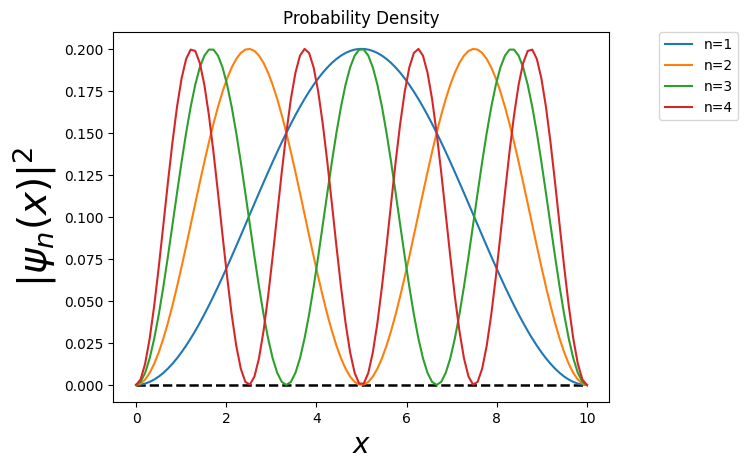

In [678]:
#CLASS ACTIVITY SOLUTION
L = 10
x = np.linspace(0, L, 100)

# Add a horizontal line at y = 0
plt.hlines(0.0, 0.0, L, linewidth=1.8, linestyle='--', color="black")

# Wavefunction
def psi(x, n, L):
    return np.sqrt(2.0 / L) * np.sin(n * np.pi * x / L)

# Probability density
def psi_square(x, n, L):
    return (2.0 / L) * np.sin(n * np.pi * x / L)**2

for n in range(1, 5):
    plt.plot(x, psi_square(x, n, L), label='n=%s' % n)

plt.xlabel(r'$x$', size=20)
plt.ylabel(r'$|\psi_n(x)|^2$', size=28)
plt.title('Probability Density')
plt.legend(bbox_to_anchor=(1.1, 1), loc=2, borderaxespad=0.0)
plt.show()

**Lab Exercise: Making Sense of Probabilistic Measurments of a Quantum System**

Imagine the following scenario.  You are working in a lab that is fabricating nanotubes with a confined electron that can effectively function as a  1D particles in a box.  You have a laser that can excite the confined electron to  different energy levels.  We then use  proprietary magic to keep the electron at that energy level before we send out particle in a box to costumers   

Something has gone wrong with our equipment however, and we can't control the power of the laser that excites the electron.  We therefore are producing  producing particle in a box models with an unknown energy level.  

The only thing that is working in our lab is our device to make measurements of the particle positions of resulting excited electron in each nanotube.  Each measurment produces a single particle position.  After we produce a nanotube we are able to make a certain # of measurments of our electron positions, and from this distribution, we want to figure out the energy level of the electron.  

As our lab is fabricating nanotubes of confined electrons to sell on ETSY, we need to know their energy levels of the electron so we can price the accordingly.  Our measurments of particle positions are expensive however, so we want to figure out the smallest number of measurments we can make to be confident about the properties of our fabricated nanotubes

Here is code to generate some experimental measurments of particle positions

It works like this
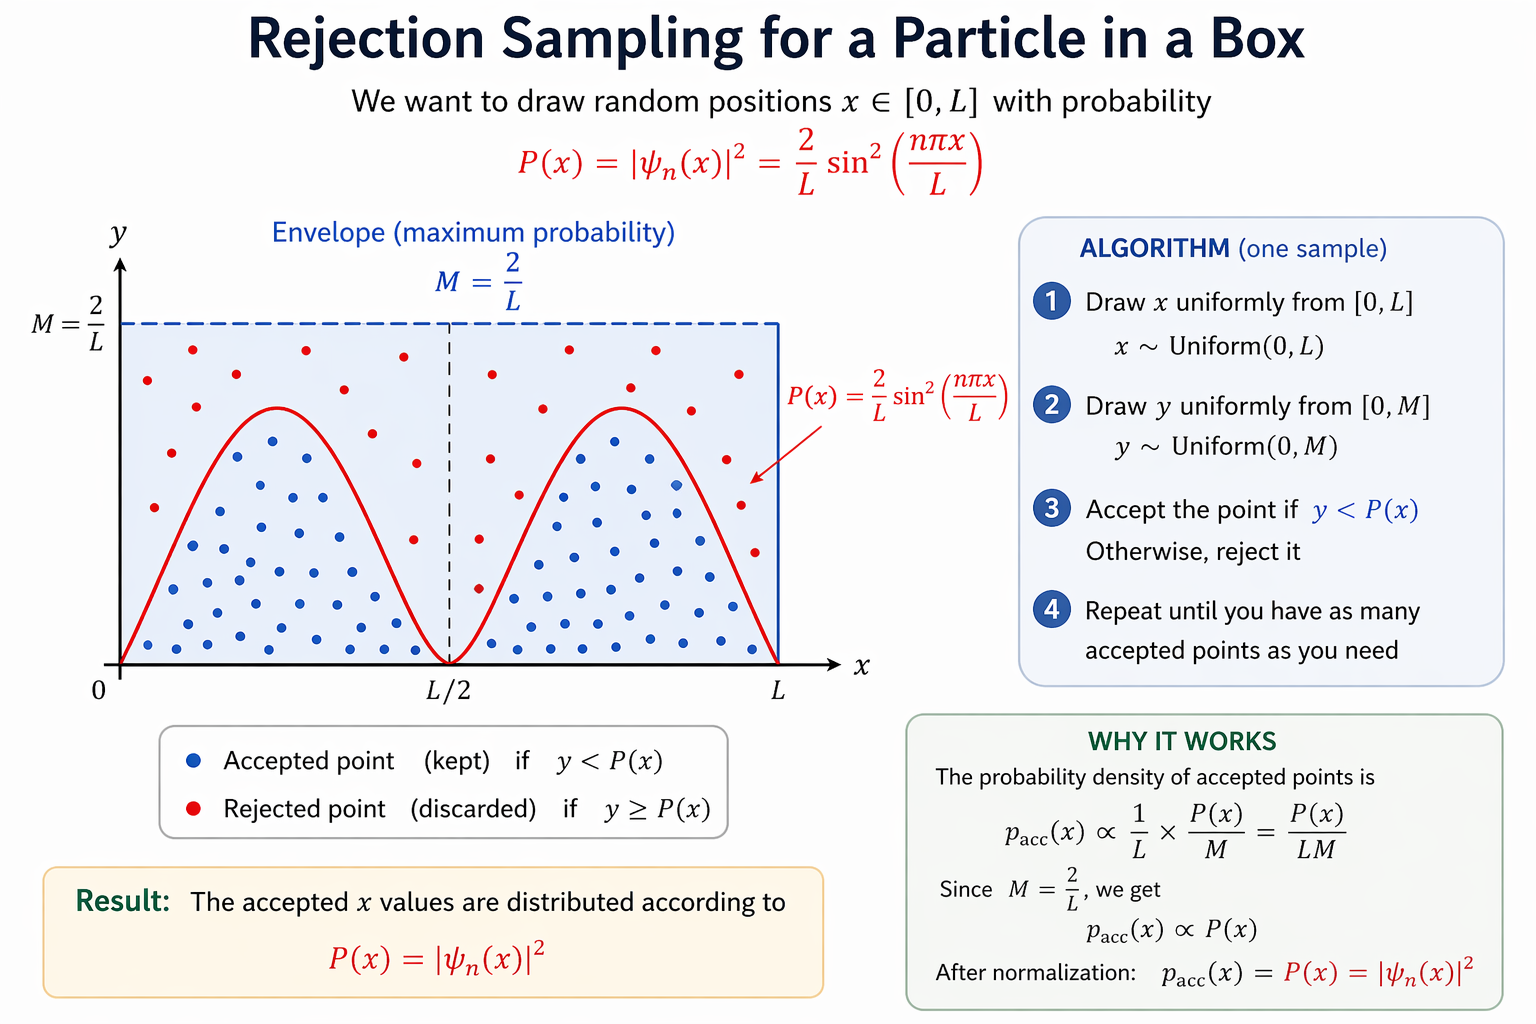


In [682]:
import numpy as np

def psi(x, n, L):
    return np.sqrt(2.0 / L) * np.sin(n * np.pi * x / L)

def probability_density(x, n, L):
    return psi(x, n, L)**2


def exp_measurement_generator(n_exp, L_exp, N_samples=100):
    samples = []

    # Maximum of probability density is 2/L
    p_max = 2.0 / L_exp

    while len(samples) < N_samples:
        # Random position in box
        x_trial = np.random.uniform(0, L_exp)

        # Random height
        y_trial = np.random.uniform(0, p_max)

        # Accept or reject
        if y_trial < probability_density(x_trial, n_exp, L_exp):
            samples.append(x_trial)

    return np.array(samples)

Now Lets compare what the histograms look like for different numbers of measurments

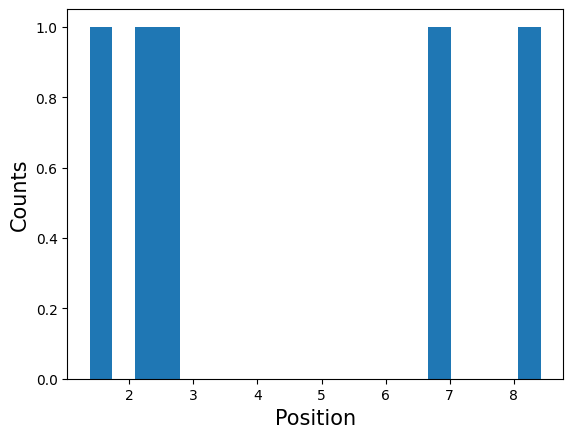

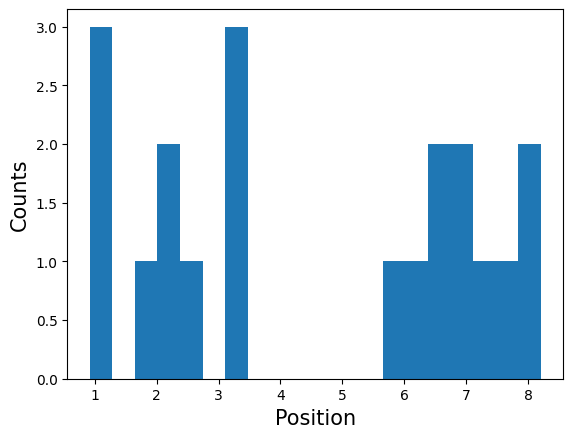

<Figure size 640x480 with 0 Axes>

In [686]:
# Parameters
n_exp = 2
L_exp = 10


n_mes1 = 5
n_mes2 = 20
POB_positions = exp_measurement_generator(n_exp, L_exp, n_mes1)

plt.hist(POB_positions, bins=20)
plt.xlabel('Position', size=15)
plt.ylabel('Counts', size=15)
plt.show()

plt.clf()

POB_positions = exp_measurement_generator(n_exp, L_exp, n_mes2)

plt.hist(POB_positions, bins=20)
plt.xlabel('Position', size=15)
plt.ylabel('Counts', size=15)
plt.show()

plt.clf()

Next Lets write a function to convert our count histogram int a probability distirbution, where the we normalize the histogram by dividing each bin by the number of counts so that the probability density we are ultimately going to fit to POB function sums to 1.



In [687]:
import numpy as np

def psi(x, n, L):
    return np.sqrt(2.0 / L) * np.sin(n * np.pi * x / L)

def probability_density(x, n, L):
    return psi(x, n, L)**2


def exp_measurement_generator(n_exp, L_exp, N_samples=100):
    samples = []

    # Maximum of probability density is 2/L
    p_max = 2.0 / L_exp

    while len(samples) < N_samples:
        # Random position in box
        x_trial = np.random.uniform(0, L_exp)

        # Random height
        y_trial = np.random.uniform(0, p_max)

        # Accept or reject
        if y_trial < probability_density(x_trial, n_exp, L_exp):
            samples.append(x_trial)

    return np.array(samples)

def convert_to_probability_density(positions, L, bins=20):
    # Force histogram to exactly span [0, L]
    counts, bin_edges = np.histogram(
        positions,
        bins=bins,
        range=(0, L),
        density=True
     )

    # Compute bin centers
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    return bin_centers, counts

Lets try this out:

We start by generating a set of particle position measurements from our “experiment,” then convert those measurements into an experimental probability density.

We will compare:
- The raw histogram (counts)
- The normalized probability density (what we use for fitting)
- The true theoretical distribution \( P(x) = |\psi(x)|^2 \)



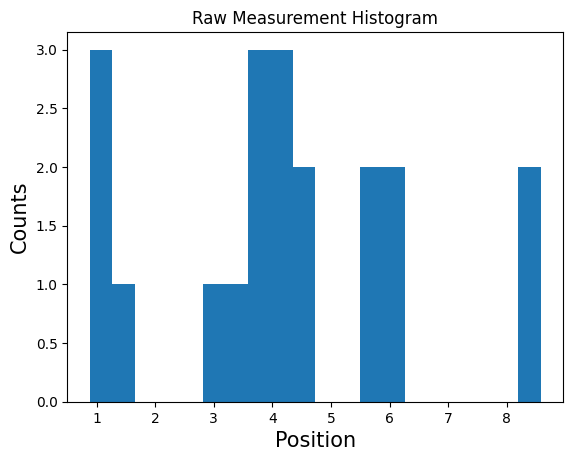

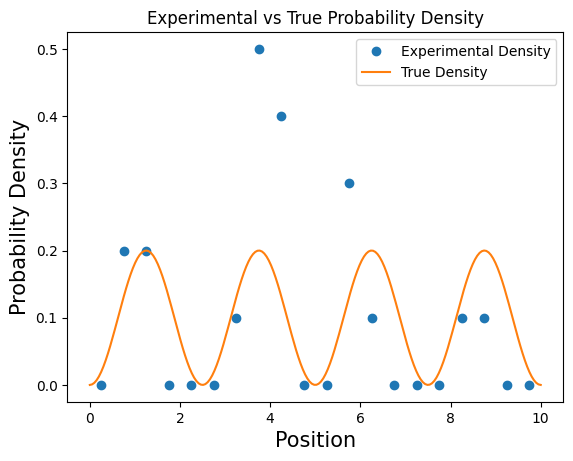

In [691]:
# Parameters
n_exp = 4
L_exp = 10

# Generate measurements
# Change this to get a better fit
n_measurements = 20
POB_positions = exp_measurement_generator(n_exp, L_exp, n_measurements)

# -------------------------
# Raw histogram (counts)
# -------------------------
plt.hist(POB_positions, bins=20)
plt.xlabel('Position', size=15)
plt.ylabel('Counts', size=15)
plt.title('Raw Measurement Histogram')
plt.show()

plt.clf()

# -------------------------
# Experimental probability density
# -------------------------
x_density, y_density = convert_to_probability_density(POB_positions, L_exp, bins=20)

# Plot experimental density
plt.plot(x_density, y_density, 'o', label='Experimental Density')

# Plot true theoretical density
x = np.linspace(0, L_exp, 200)
plt.plot(x, psi_square(x, n_exp, L_exp), label='True Density')

plt.xlabel('Position', size=15)
plt.ylabel('Probability Density', size=15)
plt.title('Experimental vs True Probability Density')
plt.legend()
plt.show()

Lets check the visual agreement between this data and different POB probability density predictions for POBs of different lengths and energy levels


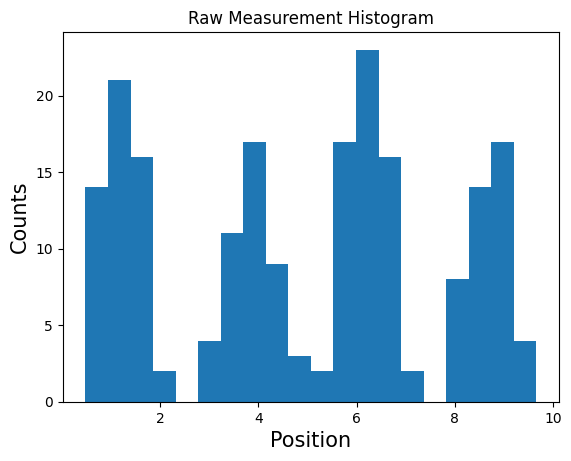

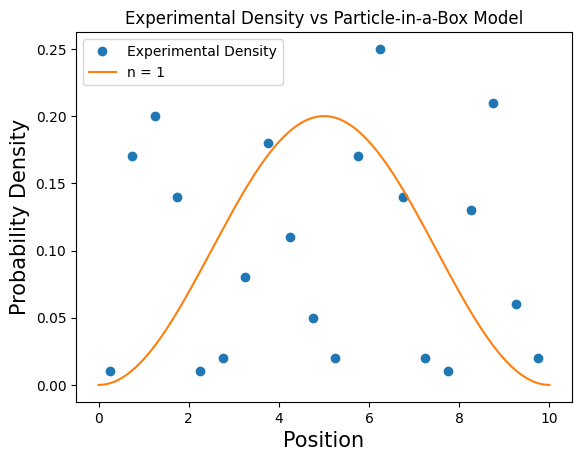

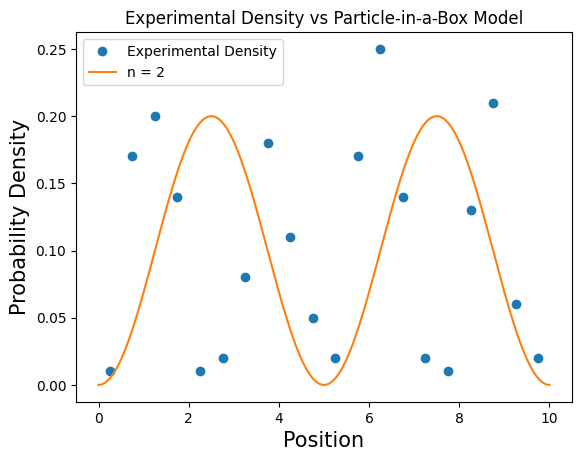

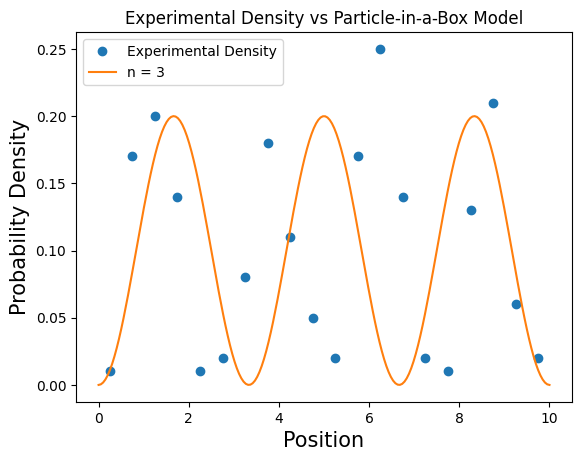

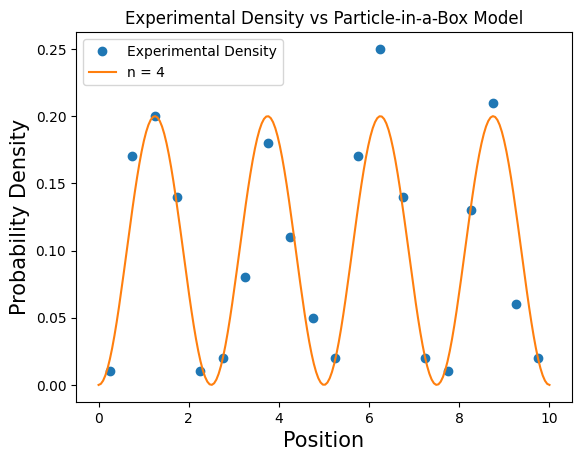

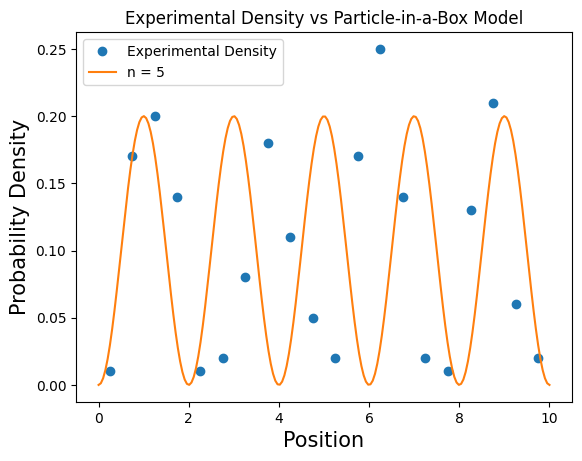

<Figure size 640x480 with 0 Axes>

In [692]:
# Let's check the visual agreement between our experimental data
# and different particle-in-a-box probability density predictions

n_exp = 4
L_exp = 10
x = np.linspace(0, L_exp, 200)

# Generate simulated position measurements
n_measurements = 200
POB_positions = exp_measurement_generator(n_exp, L_exp, n_measurements)

# Plot raw histogram
plt.hist(POB_positions, bins=20)
plt.xlabel('Position', size=15)
plt.ylabel('Counts', size=15)
plt.title('Raw Measurement Histogram')
plt.show()

plt.clf()

# Convert measurements into an experimental probability density
bin_centers, experimental_density = convert_to_probability_density(POB_positions, L_exp, bins=20)

# Compare experimental density to several candidate models
for n in range(1, 6):
    plt.plot(bin_centers, experimental_density, 'o', label='Experimental Density')
    plt.plot(x, psi_square(x, n, L_exp), label='n = %s' % n)

    plt.xlabel('Position', size=15)
    plt.ylabel('Probability Density', size=15)
    plt.title('Experimental Density vs Particle-in-a-Box Model')
    plt.legend()
    plt.show()
    plt.clf()

This Looks Pretty Easy To Discriminate Against.  Lets write a function to claculate the RMSD between our predicted probability distribution and what we measure

n: 1 RMSD: 0.30367890994641994


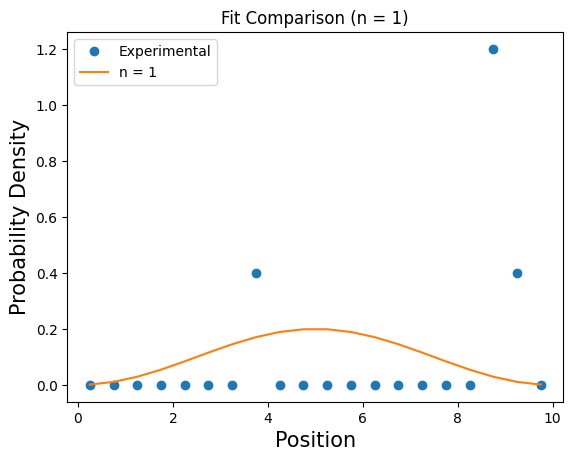

n: 2 RMSD: 0.29214917595155027


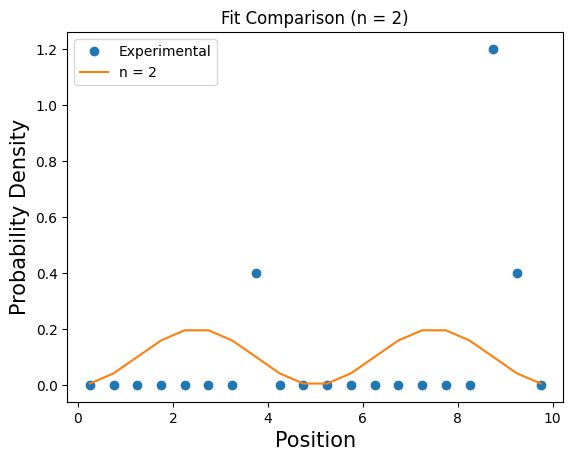

n: 3 RMSD: 0.27922908804540497


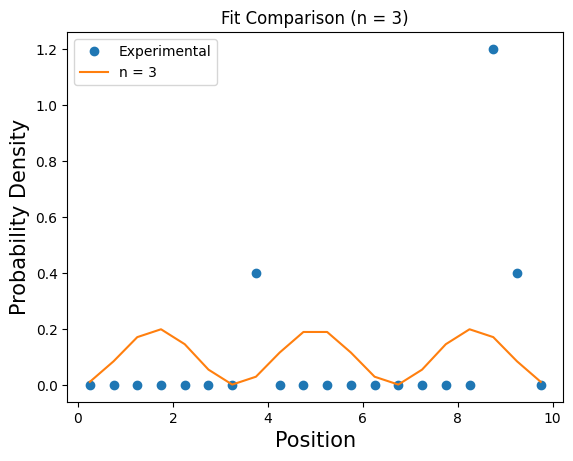

n: 4 RMSD: 0.2564447933230468


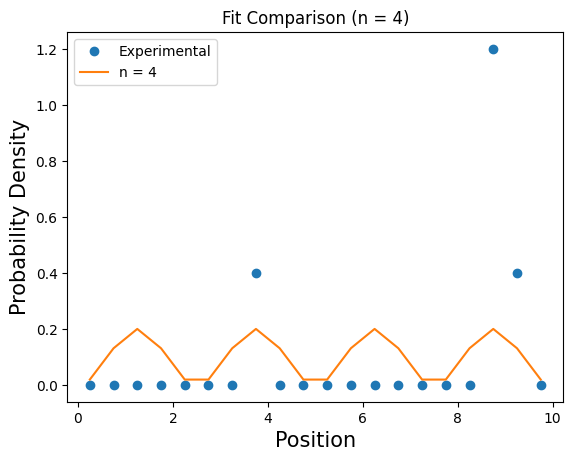

n: 5 RMSD: 0.27297384238377387


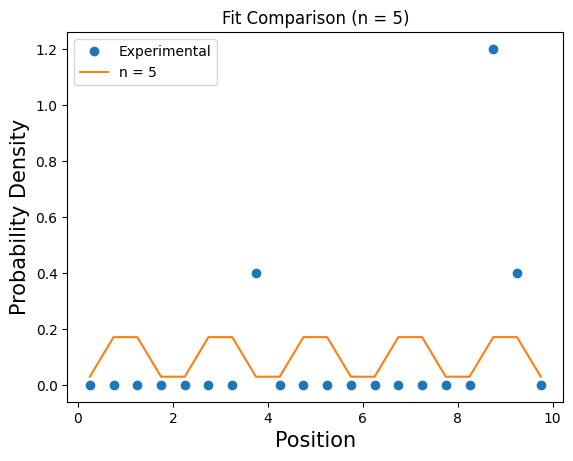

n: 6 RMSD: 0.28141743715487744


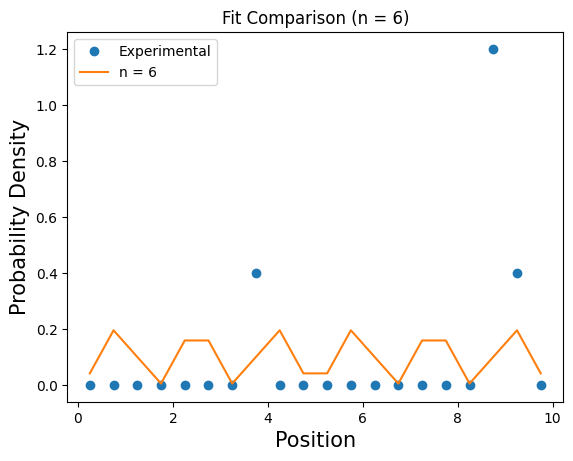

n: 7 RMSD: 0.29104312547646927


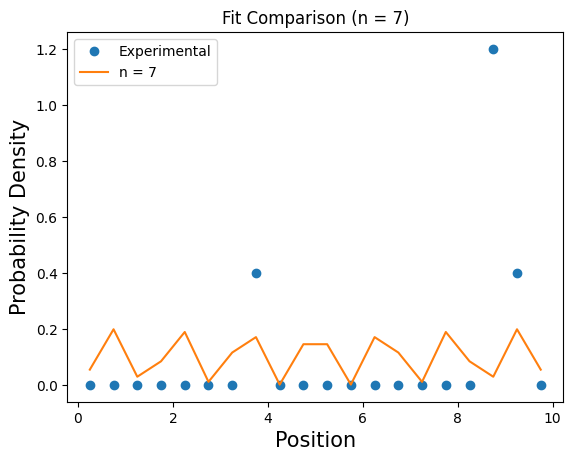

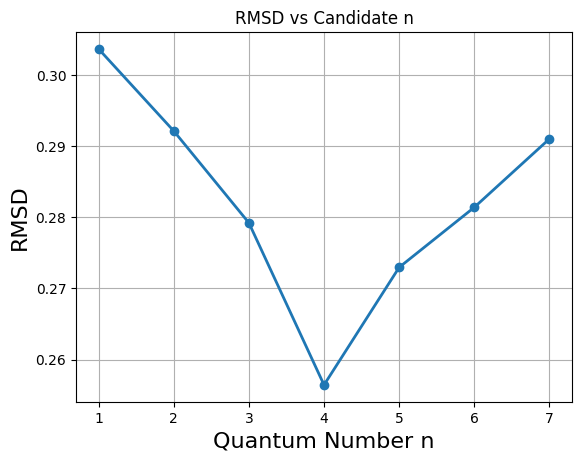

In [694]:
def calculate_RMSD(y_data, y_predicted):
    return np.sqrt(np.mean((y_data - y_predicted)**2))


rmsd = []
n_val = []
n_exp = 4
L_exp = 10
x = np.linspace(0, L_exp, 200)
# Generate simulated position measurements
n_measurements = 5

POB_positions = exp_measurement_generator(n_exp, L_exp, n_measurements)
bin_centers, experimental_density = convert_to_probability_density(POB_positions, L_exp, bins=20)

# Loop over candidate quantum numbers
for n in range(1, 8):

    # Model evaluated at SAME x-points (bin centers)
    model_density = psi_square(bin_centers, n, L_exp)
    # Compute RMSD
    RMSD = calculate_RMSD(experimental_density, model_density)

    n_val.append(n)
    rmsd.append(RMSD)

    print("n:", n, "RMSD:", RMSD)

    # Plot comparison (one figure per n)
    plt.plot(bin_centers, experimental_density, 'o', label='Experimental')
    plt.plot(bin_centers, model_density, label=f'n = {n}')

    plt.xlabel('Position', size=15)
    plt.ylabel('Probability Density', size=15)
    plt.title(f'Fit Comparison (n = {n})')
    plt.legend()
    plt.show()
    plt.clf()


#Plot RMSD vs n
plt.plot(n_val, rmsd, 'o-', linewidth=2)
plt.xlabel('Quantum Number n', size=16)
plt.ylabel('RMSD', size=16)
plt.title('RMSD vs Candidate n')
plt.grid(True)
plt.show()

**Class Activity**


Let's make a compact function to just plot RMSD as function of the number of measurements if L=100 and n=3

In [728]:
# Class Activity Scaffold

def calculate_RMSD(y_data, y_predicted):
    return np.sqrt(np.mean((y_data - y_predicted)**2))

n_exp = 4
L_exp = 10
true_n=3
x = np.linspace(0, L_exp, 200)
# Generate simulated position measurements
n_measurements = 10

POB_positions = exp_measurement_generator(n_exp, L_exp, n_measurements)
bin_centers, experimental_density = convert_to_probability_density(POB_positions, L_exp, bins=20)

#ADD CODE#
# Create Empty Lists to hold our values of n and the RMSD of our fit for that value


# Loop over candidate quantum numbers and compute RMSD
#Write for loop

model_density = psi_square(bin_centers, n, L_exp)
# Compute RMSD
RMSD = calculate_RMSD(experimental_density, model_density)

#ADD CODE#
#Append value of n and computed RMSD to our empty lists


#print the value of n and RMSD

#Plot RMSD vs n

n: 1 RMSD: 0.15941582233315202
n: 2 RMSD: 0.16069981174666964
n: 3 RMSD: 0.18396672315522306
n: 4 RMSD: 0.11793994258202146
n: 5 RMSD: 0.1643167672515498
n: 6 RMSD: 0.17000621468814106
n: 7 RMSD: 0.13599167996763517


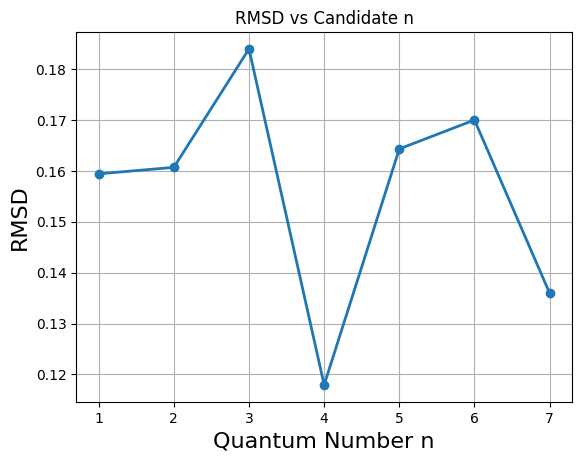

In [754]:
# Class Activity Solution

def calculate_RMSD(y_data, y_predicted):
    return np.sqrt(np.mean((y_data - y_predicted)**2))

n_exp = 4
L_exp = 10
true_n=3
x = np.linspace(0, L_exp, 200)
# Generate simulated position measurements
n_measurements = 10

POB_positions = exp_measurement_generator(n_exp, L_exp, n_measurements)
bin_centers, experimental_density = convert_to_probability_density(POB_positions, L_exp, bins=20)

#ADD CODE#
# Create Empty Lists to hold our values of n and the RMSD of our fit for that value

rmsd = []
n_value = []

# Loop over candidate quantum numbers and compute RMSD
#Write for loop
for n in range(1,8):

 model_density = psi_square(bin_centers, n, L_exp)
# Compute RMSD
 RMSD = calculate_RMSD(experimental_density, model_density)
#ADD CODE#
#Append value of n and computed RMSD to our empty lists
 n_value.append(n)
 rmsd.append(RMSD)
#print the value of n and RMSD
 print("n:", n, "RMSD:", RMSD)

#Plot RMSD vs n
plt.plot(n_value, rmsd, 'o-', linewidth=2)
#Label plot
plt.xlabel('Quantum Number n', size=16)
plt.ylabel('RMSD', size=16)
plt.title('RMSD vs Candidate n')
plt.grid(True)
plt.show()

**Class Activity**

Our ability to identify the true value of N is going to depend on the number of measurements.  

Lets repeat the cell above, varying the numbers of measurements

**CLASS ACTIVITY**

Lets add some code to just report what our answer is, and if we got the correct answer.  

We'll do this be determining the minimum value of RMSD

Lets use this function:

```python
import numpy as np

a = np.array([5, 2, 8, 1, 3])

idx = np.argmin(a)
print("Index of minimum:", idx)
print("Minimum value:", a[idx])

In [764]:
##CODE SCAFFOLD#
n_exp = 4
L_exp = 10
true_n=3
x = np.linspace(0, L_exp, 200)
# Generate simulated position measurements
n_measurements = 5

POB_positions = exp_measurement_generator(n_exp, L_exp, n_measurements)
bin_centers, experimental_density = convert_to_probability_density(POB_positions, L_exp, bins=20)

# Create Empty Lists to hold our values of n and the RMSD of our fit for that value

n_val = []
rmsd = []

# Loop over candidate quantum numbers and compute RMSD
#Write for loop
for n in range(1, 10):

    # Model evaluated at bin centers as x-points
    model_density = psi_square(bin_centers, n, L_exp)
    # Compute RMSD
    RMSD = calculate_RMSD(experimental_density, model_density)
    #Append value of n and computed RMSD to our empty lists
    n_val.append(n)
    rmsd.append(RMSD)


###ADD CODE TO CALCULATE THE MINIMUM VALUE OF THE RMSD

###ADD A FUNCTION TO REPORT IF WE GOT THE CORRECT ANSWER

In [772]:
##INSTRUCTOR SOLUTION SOLUTION##

##START BY PASTING CODE FROM ABOVE AND LETS ADD A FUNCTION THAT SAYS WHAT OUR BEST GUESS IS
###Paste Code from above, and try varying the number of measurements note how many times out of 5 you get the correct answer
n_exp = 4
L_exp = 10

x = np.linspace(0, L_exp, 200)
# Generate simulated position measurements
n_measurements = 10

POB_positions = exp_measurement_generator(n_exp, L_exp, n_measurements)
bin_centers, experimental_density = convert_to_probability_density(POB_positions, L_exp, bins=20)

# Create Empty Lists to hold our values of n and the RMSD of our fit for that value

n_val = []
rmsd = []

# Loop over candidate quantum numbers and compute RMSD
#Write for loop
for n in range(1, 10):
    # Model evaluated at bin centers as x-points
    model_density = psi_square(bin_centers, n, L_exp)
    # Compute RMSD
    RMSD = calculate_RMSD(experimental_density, model_density)
    #Append value of n and computed RMSD to our empty lists
    n_val.append(n)
    rmsd.append(RMSD)


###ADD CODE TO CALCULATE THE MINIMUM VALUE OF THE RMSD

idx = np.argmin(rmsd)
print("n with Minimum RMSD:",n_val[idx])

###ADD A FUNCTION TO REPORT IF WE GOT THE CORRECT ANSWER
n_pred=n_val[idx]
if n_pred==n_exp:
    print("Correct")
else:
    print("Incorrect")

n with Minimum RMSD: 4
Correct


**CLASS ACTIVITY**

Now lets write a loop to predict n 10 times, and report how many times we get it right.

we're going to create a variable called correct, and increment it everytime we get the answer right with this condition

```python

correct = 0

if n_pred == n_exp:
    correct += 1

print(correct)


In [831]:
## CLASS ACITIVITY SCAFFOLD

n_exp = 4
L_exp = 10
n_trials=10

x = np.linspace(0, L_exp, 200)

n_measurements = 5
#FIRST INTILIAZE THE NUMBER OF CORRECT GUESSES

#### ADD A LOOP TO TRY THIS 10 TIMES

POB_positions = exp_measurement_generator(n_exp, L_exp, n_measurements)
bin_centers, experimental_density = convert_to_probability_density(POB_positions, L_exp, bins=20)
# Create Empty Lists to hold our values of n and the RMSD of our fit for that value
n_val = []
rmsd = []
for n in range(1, 10):
    # Model evaluated at bin centers as x-points
    model_density = psi_square(bin_centers, n, L_exp)
    # Compute RMSD
    RMSD = calculate_RMSD(experimental_density, model_density)
    #Append value of n and computed RMSD to our empty lists
    n_val.append(n)
    rmsd.append(RMSD)
idx = np.argmin(rmsd)
print("n with Minimum RMSD:",n_val[idx])

###ADD A FUNCTION TO REPORT IF WE GOT THE CORRECT ANSWER


#### REPORT FRACTION CORRECT

n with Minimum RMSD: 7


In [832]:
## CLASS ACITIVITY SOLUTION

n_exp = 4
L_exp = 10
n_trials=10

x = np.linspace(0, L_exp, 200)

n_measurements = 5
#FIRST INTILIAZE THE NUMBER OF CORRECT GUESSES
correct = 0

#### ADD A LOOP TO TRY THIS 10 TIMES
for j in range(0,n_trials):

 POB_positions = exp_measurement_generator(n_exp, L_exp, n_measurements)
 bin_centers, experimental_density = convert_to_probability_density(POB_positions, L_exp, bins=20)
 # Create Empty Lists to hold our values of n and the RMSD of our fit for that value
 n_val = []
 rmsd = []
 for n in range(1, 10):
    # Model evaluated at bin centers as x-points
    model_density = psi_square(bin_centers, n, L_exp)
    # Compute RMSD
    RMSD = calculate_RMSD(experimental_density, model_density)
    #Append value of n and computed RMSD to our empty lists
    n_val.append(n)
    rmsd.append(RMSD)
 idx = np.argmin(rmsd)
 print("n with Minimum RMSD:",n_val[idx])

###ADD A FUNCTION TO REPORT IF WE GOT THE CORRECT ANSWER
 n_pred=n_val[idx]
 if n_pred==n_exp:
   correct += 1


#### REPORT FRACTION CORRECT
print("Fraction Correct:", correct / n_trials )

n with Minimum RMSD: 4
n with Minimum RMSD: 4
n with Minimum RMSD: 1
n with Minimum RMSD: 8
n with Minimum RMSD: 4
n with Minimum RMSD: 2
n with Minimum RMSD: 4
n with Minimum RMSD: 6
n with Minimum RMSD: 4
n with Minimum RMSD: 4
Fraction Correct: 0.6


**Lab Exercise 1**
Lets make a quantative plot to compare the RMSD of the deviations of probability distirbutions when we have 3,5,10,20,100 measurements if n_exp=3 and Lexp=10.  

Plot RSMD vs number of measurements all on the same plot.  Start with scaffold below that makes the plot for 10 measurements

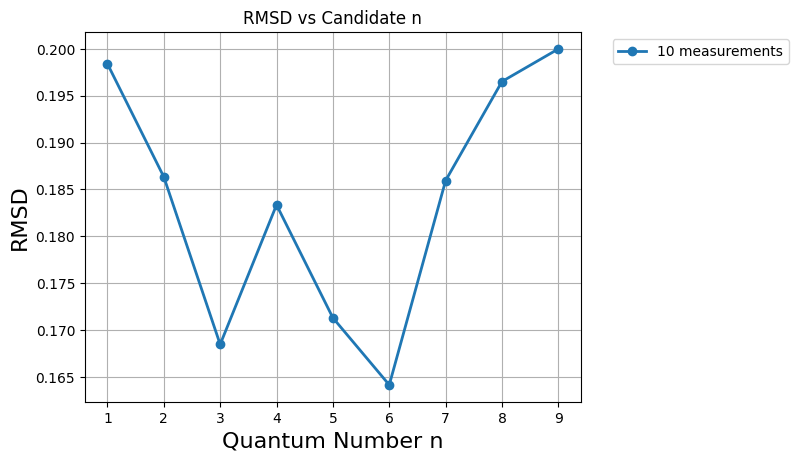

In [835]:
### LAB EXERCISE 1 SCAFFOLD
n_exp = 3
L_exp = 10
true_n=3
x = np.linspace(0, L_exp, 200)

# Generate simulated position measurements
n_measurements = 10

POB_positions = exp_measurement_generator(n_exp, L_exp, n_measurements)
bin_centers, experimental_density = convert_to_probability_density(POB_positions, L_exp, bins=20)

# Create Empty Lists to hold our values of n and the RMSD of our fit for that value
n_val = []
rmsd = []

# Loop over candidate quantum numbers and compute RMSD
#Write for loop
for n in range(1, 10):

    # Model evaluated at bin centers as x-points
    model_density = psi_square(bin_centers, n, L_exp)
    # Compute RMSD
    RMSD = calculate_RMSD(experimental_density, model_density)
    #Append value of n and computed RMSD to our empty lists
    n_val.append(n)
    rmsd.append(RMSD)
    #print the value of n and RMSD
    #print("n:", n, "RMSD:", RMSD)

#Plot RMSD vs n
plt.plot(n_val, rmsd, 'o-', linewidth=2,label=f'{n_measurements} measurements')
plt.xlabel('Quantum Number n', size=16)
plt.ylabel('RMSD', size=16)
plt.title('RMSD vs Candidate n')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

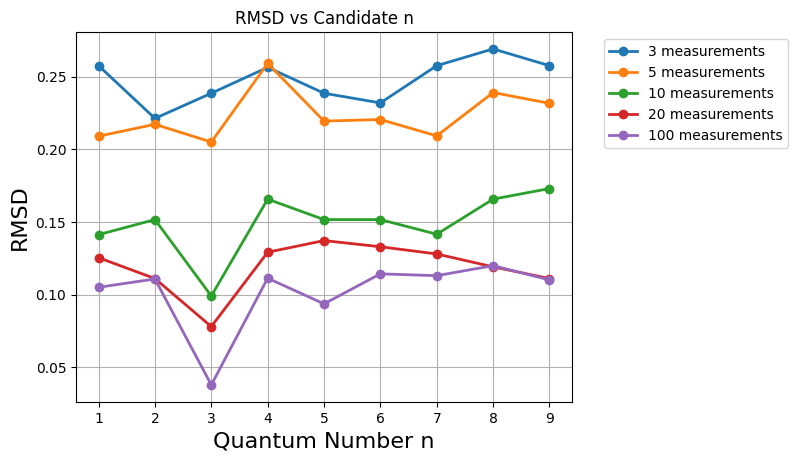

In [836]:
### INSTRUCTOR SOLUTION ####
n_exp = 3
L_exp = 10
true_n=3
x = np.linspace(0, L_exp, 200)

# Generate simulated position measurements
n_measurement_array = np.array([3,5,10,20,100])
for j in range(0,len(n_measurement_array)) :
 n_measurements=n_measurement_array[j]
 POB_positions = exp_measurement_generator(n_exp, L_exp, n_measurements)
 bin_centers, experimental_density = convert_to_probability_density(POB_positions, L_exp, bins=20)

 # Create Empty Lists to hold our values of n and the RMSD of our fit for that value
 n_val = []
 rmsd = []

 # Loop over candidate quantum numbers and compute RMSD
 #Write for loop
 for n in range(1, 10):

    # Model evaluated at bin centers as x-points
    model_density = psi_square(bin_centers, n, L_exp)
    # Compute RMSD
    RMSD = calculate_RMSD(experimental_density, model_density)
    #Append value of n and computed RMSD to our empty lists
    n_val.append(n)
    rmsd.append(RMSD)
    #print the value of n and RMSD
    #print("n:", n, "RMSD:", RMSD)

#Plot RMSD vs n

 plt.plot(n_val, rmsd, 'o-', linewidth=2,label=f'{n_measurements} measurements')

plt.xlabel('Quantum Number n', size=16)
plt.ylabel('RMSD', size=16)
plt.title('RMSD vs Candidate n')
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

**Lab Exercise 2**
Lets calculate fraction of correct guesses of the value of n when we have 3,5,10,20 and 100[link text](https://) measurements if n_exp=3 and Lexp=10.


In [840]:
##Initial Code to Modify##
n_exp = 3
L_exp = 10
true_n=3
x = np.linspace(0, L_exp, 200)

correct = 0
n_trials = 100
for j in range(0,n_trials):
 ##START BY PASTING CODE FROM ABOVE AND LETS ADD A FUNCTION THAT SAYS WHAT OUR BEST GUESS IS
 ###Paste Code from above, and try varying the number of measurements note how many times out of 5 you get the correct answer
 # Generate simulated position measurements
 n_measurements = 10
 POB_positions = exp_measurement_generator(n_exp, L_exp, n_measurements)
 bin_centers, experimental_density = convert_to_probability_density(POB_positions, L_exp, bins=20)

 # Create Empty Lists to hold our values of n and the RMSD of our fit for that value

 n_val = []
 rmsd = []

 # Loop over candidate quantum numbers and compute RMSD
 #Write for loop
 for n in range(1, 10):

    # Model evaluated at bin centers as x-points
    model_density = psi_square(bin_centers, n, L_exp)
    # Compute RMSD
    RMSD = calculate_RMSD(experimental_density, model_density)
    #Append value of n and computed RMSD to our empty lists
    n_val.append(n)
    rmsd.append(RMSD)

 idx = np.argmin(rmsd)
 #print("n with Minimum RMSD:",n_val[idx])

###ADD A FUNCTION TO REPORT IF WE GOT THE CORRECT ANSWER
 n_pred=n_val[idx]
 if n_pred==n_exp:
    correct += 1

print(correct)
print("Fraction Correct:", correct / n_trials )

78
Fraction Correct: 0.78


In [844]:
##INSTRUCTOR SOLUTION#
n_exp = 3
L_exp = 10
true_n=3
x = np.linspace(0, L_exp, 200)

n_measurement_array = np.array([3,5,10,20,100])
for k in range(0,len(n_measurement_array)) :
 n_measurements = n_measurement_array[k]

 correct = 0
 n_trials = 100
 for j in range(0,n_trials):
  ##START BY PASTING CODE FROM ABOVE AND LETS ADD A FUNCTION THAT SAYS WHAT OUR BEST GUESS IS
  ###Paste Code from above, and try varying the number of measurements note how many times out of 5 you get the correct answer
  # Generate simulated position measurements
  POB_positions = exp_measurement_generator(n_exp, L_exp, n_measurements)
  bin_centers, experimental_density = convert_to_probability_density(POB_positions, L_exp, bins=20)

  # Create Empty Lists to hold our values of n and the RMSD of our fit for that value

  n_val = []
  rmsd = []

  # Loop over candidate quantum numbers and compute RMSD
  #Write for loop
  for n in range(1, 10):

    # Model evaluated at bin centers as x-points
    model_density = psi_square(bin_centers, n, L_exp)
    # Compute RMSD
    RMSD = calculate_RMSD(experimental_density, model_density)
    #Append value of n and computed RMSD to our empty lists
    n_val.append(n)
    rmsd.append(RMSD)

  idx = np.argmin(rmsd)
 #print("n with Minimum RMSD:",n_val[idx])

###ADD A FUNCTION TO REPORT IF WE GOT THE CORRECT ANSWER
  n_pred=n_val[idx]
  if n_pred==n_exp:
    correct += 1

 print(n_measurements,"Fraction Correct:", correct / n_trials )

3 Fraction Correct: 0.37
5 Fraction Correct: 0.53
10 Fraction Correct: 0.74
20 Fraction Correct: 0.93
100 Fraction Correct: 1.0


**Lab Problem 3**
Can you think of 2 pairs of values of L and n that should be especially hard to get right in a small number of measurements?  

Justify your thinking and test the hypothesis with code

**ADD YOUR JUSTIFICAITON HERE**

In [634]:
##ADD YOUR CODE TO TEST THIS HERE##